# MVP Análise de Dados e Boas Práticas

**Nome:** Bruno Rocha do Nascimento

**Matrícula:** 4052025002341

**Dataset:** [IBM HR Analytics Employee Attrition & Performance](https://raw.githubusercontent.com/BrunoSennin/MVP_Bruno_Rocha_Nascimento/refs/heads/main/WA_Fn-UseC_-HR-Employee-Attrition.csv)

# Descrição do Problema

Atualmente grandes companhias enfrentam problemas relacionados à retenção de talentos, se tornando um dos principais desafios para a área de Recursos Humanos. A saída repentina de colaboradores gera impactos financeiros, operacionais e estratégicos, muitas vezes gerando aumento nos custos de recrutamento e seleção, perda do capital intelectual e redução da produtividade.

Com base nisso, esse MVP tem como proposta utilizar a análise de dados para compreender os principais fatores que influenciam na rotatividade de colaboradores.

Com essa análise pode-se gerar dados para apoiar decisões para área de Recursos Humanos sobre como atuar de forma preventiva, contribuindo para elaborar novas estratégias de retenção, de reestruturação organizacional de processos e promover um ambiente organizacional mais saudável e sustentável.

Este projeto utiliza um conjunto de dados contendo informações sobre colaboradores de uma empresa, incluindo aspectos demográficos, financeiros e relacionados ao ambiente de trabalho.

## Hipóteses do Problema

A análise foi estruturada em duas etapas:

1. **Exploratória**: Com o objetivo de identificar qual o departamento com maior índice de rotatividade.

2. **Diagnóstica**: Após identificar o departamento com maior índice de rotatividade, essa etapa tem o objetivo de identificar as causas que possivelmente justificam esse índice.

A partir das análises estabelecidas temos as seguinte hipóteses levantadas

1. **Qual departamento apresenta mais rotatividade de colaboradores?**

2. **Colaboradores com menor nível salarial apresentam maior probabilidade de saída?**

3. **Baixos níveis de satisfação no trabalho influenciam a decisão de saída?**

4. **O desequilíbrio entre vida pessoal e profissional contribui para a rotatividade?**

5. **Colaboradores com maior tempo sem promoção tendem a deixar a empresa?**

6. **Há uma correlação entre gênero e a rotatividade?**


## Tipo de Problema

Este é um problema de **classificação supervisionada**. Dado um conjunto de características dos colaboradores, como idade, salário mensal, satisfação no trabalho, tempo de empresa e equilíbrio entre vida pessoal e profissional, o objetivo é analisar os fatores associados à saída de colaboradores (rotatividade).

## Seleção de Dados

O dataset utilizado neste projeto é o **IBM HR Analytics Employee Attrition & Performance**, amplamente disponível em repositórios públicos de dados, como o Kaggle.


## Atributos do Dataset

O dataset possui **1.470 registros** e **35 atributos**, contemplando informações demográficas, profissionais e organizacionais dos colaboradores.

A variável principal de interesse é **Rotatividade**, que indica se o colaborador deixou ou permaneceu na empresa.

Considerando o objetivo deste estudo, optou-se por focar nos atributos mais relevantes para a análise das hipóteses propostas, especialmente aqueles relacionados a fatores organizacionais e pessoais.

Dentre os principais atributos utilizados, destacam-se:

- **Departamento**: área de atuação do colaborador.
- **Salario_Mensal**: remuneração mensal.
- **Satisfacao_Trabalho**: nível de satisfação no trabalho.
- **Equilibrio_Vida_Trabalho**: percepção de equilíbrio entre vida pessoal e profissional.
- **Tempo_Empresa**: tempo de permanência na empresa.
- **Tempo_Ultima_Promocao**: tempo desde a última promoção.
- **gênero**: gênero do colaborador.

A seleção dos atributos foi orientada pelas hipóteses definidas no estudo, buscando focar nas variáveis com maior potencial explicativo sobre a rotatividade.

## Legenda de Atributos

Para facilitar a interpretação das análises realizadas neste estudo, seguem as descrições dos seguintes atributos:

- **Satisfacao_Trabalho**: nível de satisfação do colaborador em relação ao trabalho, representado pela seguinte escala:
  - 1 = Baixa
  - 2 = Média
  - 3 = Alta
  - 4 = Muito Alta

- **Equilibrio_Vida_Trabalho**: percepção do colaborador sobre o equilíbrio entre vida pessoal e profissional, representado pela escala:
  - 1 = Ruim
  - 2 = Bom
  - 3 = Melhor
  - 4 = Excelente

Para os atributos de **Tempo_Empresa** e **Tempo_Ultima_Promocao** os valores são representados em anos inteiros.

# Importação das Bibliotecas Necessárias e Carga de Dados

Foram importadas bibliotecas voltadas à manipulação, análise e visualização dos dados, além de recursos para pré-processamento. Também será realizado a carga de dados inicial do dataset utilizado.


In [209]:
# Manipulação de dados e operações numéricas
import pandas as pd
import numpy as np

# Visualização de dados e construção de gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e padronização de dados
from sklearn.preprocessing import StandardScaler

In [210]:
# Definição do link do Github a partir da variável url
url = "https://raw.githubusercontent.com/BrunoSennin/MVP_Bruno_Rocha_Nascimento/refs/heads/main/WA_Fn-UseC_-HR-Employee-Attrition.csv"


In [211]:
# Armazenar o link em um dataframe
df = pd.read_csv(url)

In [212]:
# Leitura inicial das primeiras linhas
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Percepções da carga de dados

Ao observar as primeiras linhas, notamos que há alguns atributos descartáveis que não estão alinhados inicialmente com as hipóteses levantadas anteriormente.

# Análise de Dados

Nesta etapa de Análise Exploratória de Dados (EDA), temos o objetivo de compreender a estrutura, distribuição e características das variáveis presentes no dataset de rotatividade de colaboradores. Sendo possível identificar padrões inicias, possíveis inconsistências e fatores relevantes que servirão de base para analisar diagnóstica proposta.

## Total e Tipo das Instâncias

O dataset analisado possui 1470 instâncias e 35 atributos. Os atributos são distribuidos em duas caractéristicas **numéricas inteiras** (int64) e **categóricas** (object), como demonstrado.

In [213]:
# Informações sobre o dataset
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 1470

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement          

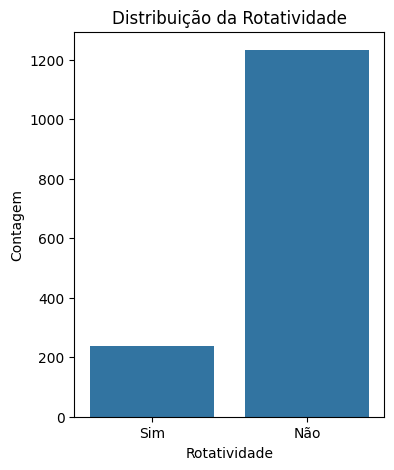

In [214]:
#Para validar a distribuição da rotatividade utilizaremos um gráfico de barras simples
# Para melhor compreender os dados vamos traduzir valores
df['Attrition'] = df['Attrition'].replace({'Yes': 'Sim','No': 'Não'})
# Gráfico
plt.figure(figsize=(4,5))
sns.countplot(x='Attrition', data=df)

plt.title('Distribuição da Rotatividade')
plt.xlabel('Rotatividade')
plt.ylabel('Contagem')
plt.show()

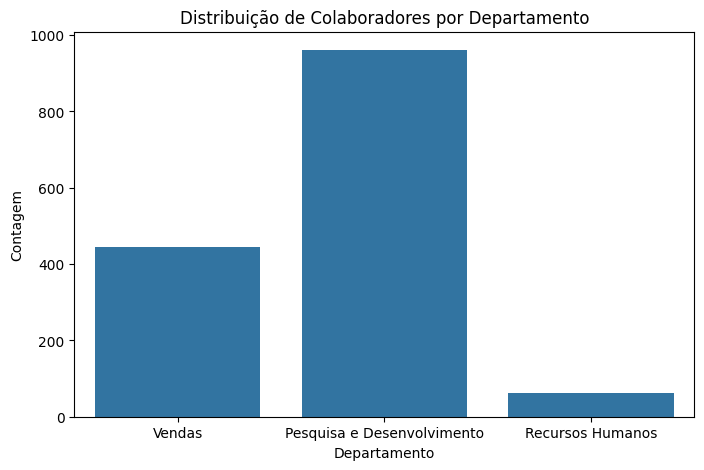

In [215]:
# Utilizaremos mais um gráfico de barras para validar a quantidade de resposta por departamento
# Para facilitar a interpretação vamos traduzir os dados
df['Department'] = df['Department'].replace({'Sales': 'Vendas', 'Research & Development': 'Pesquisa e Desenvolvimento', 'Human Resources': 'Recursos Humanos'})
# Gráfico
plt.figure(figsize=(8, 5))
sns.countplot(x='Department', data=df)
plt.title('Distribuição de Colaboradores por Departamento')
plt.xlabel('Departamento')
plt.ylabel('Contagem')
plt.show()

Observa-se predominância de colaboradores que permaneceram na empresa e a distribuição por departamento, indicando desbalanceamento entre as classes.

## Valores Nulos e Duplicados

Não foram encontrados valores nulos ou duplicados, conforme demonstrado.

In [216]:
# Verificação dos valores duplicados
df.duplicated().sum()

np.int64(0)

In [217]:
# Verificação se há dados nulos no dataset
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


## Análise Exploratória

Como mencionado será realizado uma análise exploratória para identificar o departamento com mais rotatividade e a partir daí realizarmos uma análise descritiva mais focada no departamento encontrado.

In [218]:
# Ja sabemos por análise prévia que há desbalanceamento de dados
# Vamos identificar a quantidade de colaboradores por departamento
print('Colaboradores por Departamento')
print(df['Department'].value_counts())

Colaboradores por Departamento
Department
Pesquisa e Desenvolvimento    961
Vendas                        446
Recursos Humanos               63
Name: count, dtype: int64


In [219]:
# Agora vamos identificar a distribuição pela quantidade de rotatividade por departamento
print('Rotatividade por Departamento')
print(df[df['Attrition'] == 'Sim']['Department'].value_counts())

Rotatividade por Departamento
Department
Pesquisa e Desenvolvimento    133
Vendas                         92
Recursos Humanos               12
Name: count, dtype: int64


Podemos notar que por essa análise temos mais rotatividade na área de Pesquisa e Desenvolvimento, porém, esse tipo de análise pode ser falha quando comparado com a totalidade de colaboradores da área, influenciando assim a tomada de decisão. Para isso vamos determinar em percentual qual área possui o índice de maior rotatividade.

In [220]:
# Realizamos o indice (%) por departamento
indice_rotatividade = (df[df['Attrition'] == 'Sim']['Department'].value_counts()
    / df['Department'].value_counts()* 100).round(2)
print("Índice de rotatividade por departamento (%):")
print(indice_rotatividade)

Índice de rotatividade por departamento (%):
Department
Pesquisa e Desenvolvimento    13.84
Vendas                        20.63
Recursos Humanos              19.05
Name: count, dtype: float64


Já podemos perceber que o o índice de Vendas é maior do que os demais departamentos analisados. Para melhor demonstração vamos analisar via gráfico.

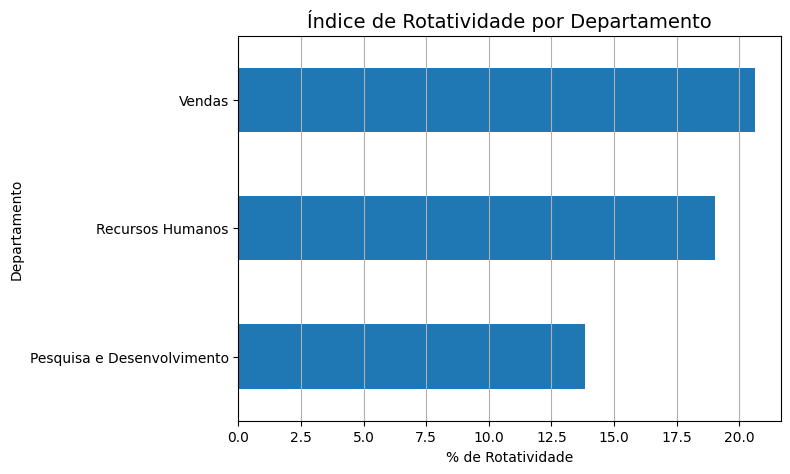

In [221]:
# Utilizamos um gráfico de barras horizontais para melhor demonstração
indice_rotatividade.sort_values().plot(kind='barh',figsize=(7,5))
plt.title('Índice de Rotatividade por Departamento', fontsize=14)
plt.xlabel('% de Rotatividade')
plt.ylabel('Departamento')
plt.grid(axis='x')
plt.show()

Com isso conclui-se que o departamento com mais rotatividade é o **Departamento de Vendas** e este que será analisado a fundo neste projeto.

## Estatisticas Descritiva

As estatisticas descritivas fornecem um resumo das variáveis numéricas, incluindo média, moda, mediana, desvio padrão, valores mínimos, máximos e quartis.

Conforme definimos na análise exploratória o departamento que será avaliado será o de **Vendas** tornando a análise mais profunda.

In [222]:
# Vamos realizar uma cópia do dataset especificando apenas o departamento de vendas
df_vendas = df[df['Department'] == 'Vendas'].copy()

In [223]:
# Com um dataset atualizado temos uma nova quantidade de instâncias
print(f"Total de instâncias: {len(df_vendas)}")

Total de instâncias: 446


In [224]:
# Com isso agora podemos seguir com a análise descritiva sem afetar o dataset original
df_vendas.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,446.000000,446.000000,446.000000,446.000000,446.0,446.000000,446.000000,446.000000,446.000000,446.000000,...,446.000000,446.0,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000
mean,36.542601,800.275785,9.365471,2.934978,1.0,1038.946188,2.679372,65.520179,2.701794,2.255605,...,2.695067,80.0,0.773543,11.105381,2.847534,2.816143,7.284753,4.486547,2.354260,4.271300
std,9.032611,402.797474,8.086808,1.031105,0.0,599.722536,1.084259,20.354461,0.705259,0.927557,...,1.114288,0.0,0.840182,7.597168,1.244884,0.675284,6.234885,3.660116,3.353357,3.643117
min,18.000000,107.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,472.000000,2.000000,2.000000,1.0,513.750000,2.000000,48.000000,2.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,35.000000,770.500000,7.000000,3.000000,1.0,991.000000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,6.000000,3.000000,1.000000,3.000000
75%,42.000000,1171.000000,13.000000,4.000000,1.0,1566.500000,4.000000,83.000000,3.000000,3.000000,...,4.000000,80.0,1.000000,14.750000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2065.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,38.000000,6.000000,4.000000,37.000000,17.000000,15.000000,17.000000


Para melhor objetivar a análise dos dados vamos focar nos atributos pré-definidos e que possuem melhor relação com as hipóteses já levantadas, que são:

- **Salario_Mensal**: remuneração mensal.
- **Satisfacao_Trabalho**: nível de satisfação no trabalho.
- **Equilibrio_Vida_Trabalho**: percepção de equilíbrio entre vida pessoal e profissional.
- **Tempo_Empresa**: tempo de permanência na empresa.
- **Tempo_Ultima_Promocao**: tempo desde a última promoção.

Além dos atributos pré-definidos também vamos considerar neste primeiro momento também o atributo **Idade** para a análise descritiva.


In [225]:
# A fim de falicitar a análise descritiva vamos atribuir uma variavél aos atributos

# Usando os nomes das colunas corretos do DataFrame
atributos_numericos = ['MonthlyIncome','JobSatisfaction',
                       'WorkLifeBalance','YearsAtCompany',
                       'YearsSinceLastPromotion','Age']

# Estalecemos uma novo dataframe e criarmos uma cópia para especificar as análises de dados
df_analise = df_vendas[atributos_numericos].copy()

# Aproveitamos para traduzir os valores das variáveis
df_analise = df_analise.rename(columns={'MonthlyIncome': 'Salario_Mensal',
                                        'JobSatisfaction': 'Satisfacao_Trabalho',
                                        'WorkLifeBalance': 'Equilibrio_Vida_Trabalho',
                                        'YearsAtCompany': 'Tempo_Empresa',
                                        'YearsSinceLastPromotion':
                                        'Tempo_Ultima_Promocao',
                                        'Age': 'Idade'})
df_analise.head()

,Salario_Mensal,Satisfacao_Trabalho,Equilibrio_Vida_Trabalho,Tempo_Empresa,Tempo_Ultima_Promocao,Idade
0,5993,4,1,6,0,41
18,15427,4,3,25,3,53
21,3407,1,3,5,0,36
27,6825,2,3,9,4,42
29,18947,1,2,2,2,46


## Média

A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (outliers).

In [226]:
# Realizar a média dos atributos selecionados com valores arredondados
print("Média dos atributos numéricos:")
print(df_analise.mean().round(2))

Média dos atributos numéricos:
Salario_Mensal              6959.17
Satisfacao_Trabalho            2.75
Equilibrio_Vida_Trabalho       2.82
Tempo_Empresa                  7.28
Tempo_Ultima_Promocao          2.35
Idade                         36.54
dtype: float64


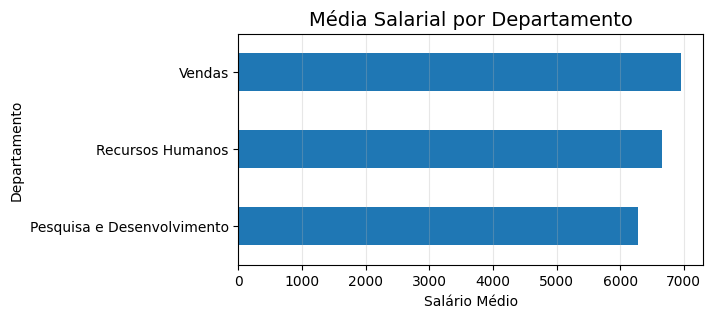

In [227]:
# Aproveitamos para avaliar a média salarial entre os departamentos com o gráfico de barras
media_departamento = df.groupby('Department')['MonthlyIncome'].mean().round(2)
media_departamento.sort_values().plot(kind='barh',figsize=(6,3))
plt.title('Média Salarial por Departamento', fontsize=14)
plt.xlabel('Salário Médio')
plt.ylabel('Departamento')
plt.grid(axis='x', alpha=0.3)
plt.show()

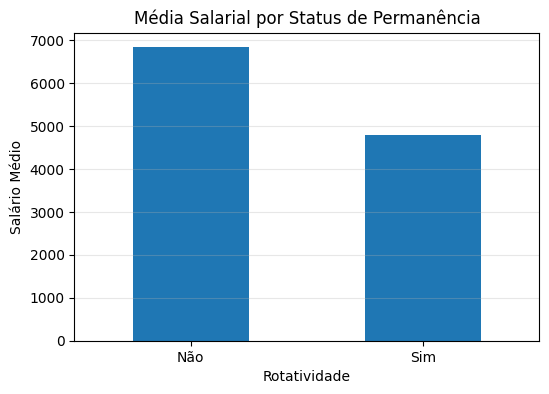

In [228]:
# Também analisamos a média salarial contra a rotatividade
media_attrition = df.groupby('Attrition')['MonthlyIncome'].mean().round(2)
media_attrition.plot(kind='bar',figsize=(6,4))
plt.title('Média Salarial por Status de Permanência')
plt.xlabel('Rotatividade')
plt.ylabel('Salário Médio')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

Com base na análise prévia do valor média salarial, notamos que o departamento de Vendas possui a média salarial maior do que os demais departamentos, além de que os colaboradores que permanecem na companhia possuem uma média maior de salário daqueles que sairam.

## Desvio Padrão

O desvio padrão é uma medida de dispersão que quantifica a quantidade de variação ou dispersão de um conjunto de valores. Um desvio padrão baixo indica que os pontos de dados tendem a estar próximos da média do conjunto, enquanto um desvio padrão alto indica que os pontos de dados estão espalhados por uma faixa maior de valores. Ele é a raiz quadrada da variância.

In [229]:
# Realizar o desvio padrão dos atributos selecionados com valores arredondados
print("Desvio padrão dos atributos numéricos:")
print(df_analise.std().round(2))

Desvio padrão dos atributos numéricos:
Salario_Mensal              4058.74
Satisfacao_Trabalho            1.11
Equilibrio_Vida_Trabalho       0.68
Tempo_Empresa                  6.23
Tempo_Ultima_Promocao          3.35
Idade                          9.03
dtype: float64


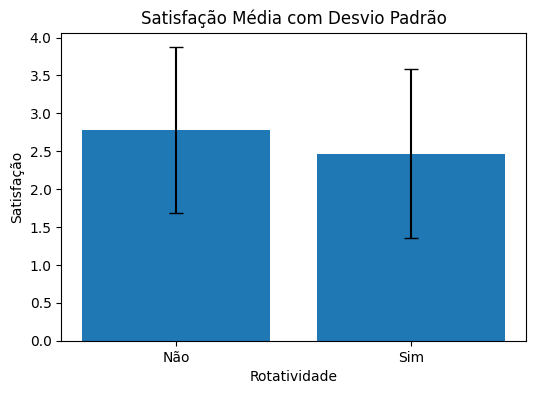

In [230]:
# Vamos analisar se o desvio padrão sobre a média de satisfação no trabalho dispersam sobre a rotatividade
estatistica = df.groupby('Attrition')['JobSatisfaction'].agg(['mean', 'std']).round(2)
plt.figure(figsize=(6,4))
plt.bar(estatistica.index,estatistica['mean'],yerr=estatistica['std'],capsize=5)
plt.title('Satisfação Média com Desvio Padrão')
plt.xlabel('Rotatividade')
plt.ylabel('Satisfação')
plt.show()

Com esse resultado podemos notar que os valores de desvio padrão variam pouco entre os grupos de rotatividade referente a média de satisfação no trabalho apresentada.

## Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

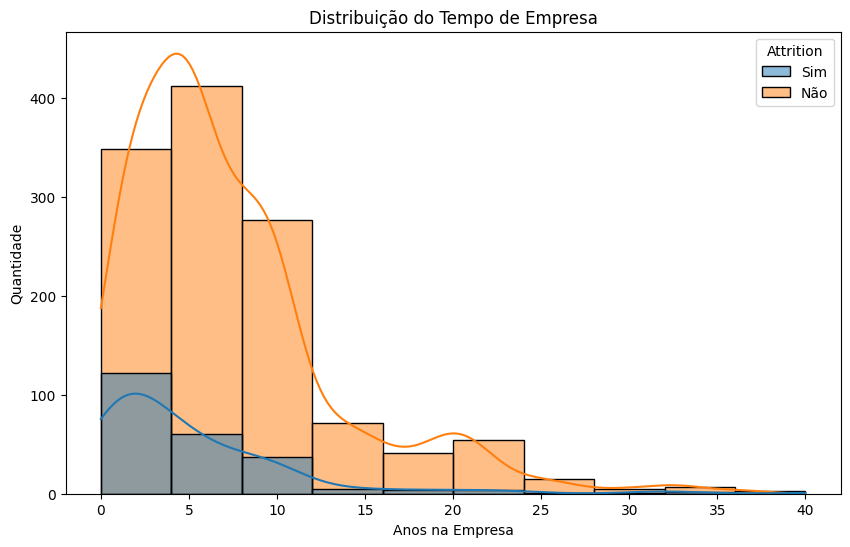

In [231]:
# Utilizamos o histograma para verificar qual a tendência de rotatividade por tempo de empresa
plt.figure(figsize=(10,6))
sns.histplot(data=df,x='YearsAtCompany',hue='Attrition',kde=True,bins=10,
             stat='count',alpha=0.5)
plt.title('Distribuição do Tempo de Empresa')
plt.xlabel('Anos na Empresa')
plt.ylabel('Quantidade')
plt.show()

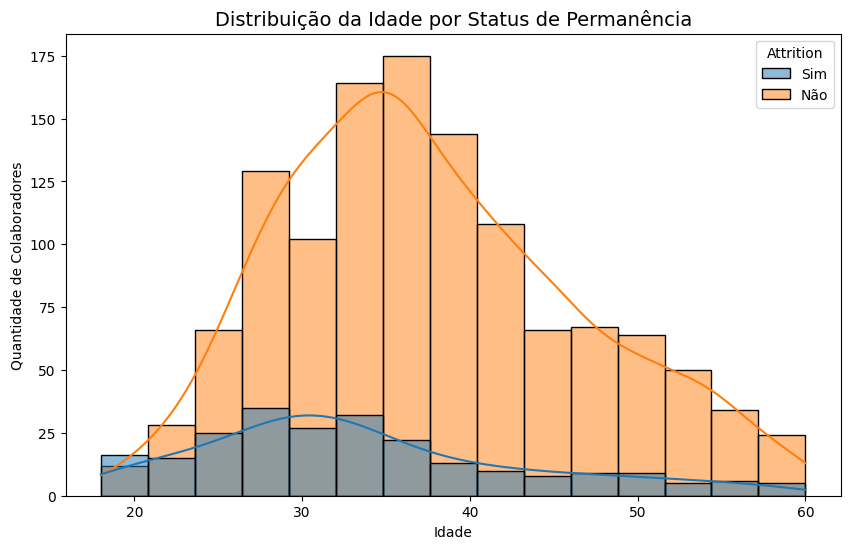

In [232]:
# Também vamos analisar o a tendência por idade
plt.figure(figsize=(10,6))
sns.histplot(data=df,x='Age',hue='Attrition',kde=True,bins=15,alpha=0.5,
             stat='count')
plt.title('Distribuição da Idade por Status de Permanência', fontsize=14)
plt.xlabel('Idade')
plt.ylabel('Quantidade de Colaboradores')
plt.show()

Analisando os histogramas possuímos uma tendência de rotatividade para colaboradores entre os primeiros anos da organização e que isso pode estar relacionada a idade de saída que fica entre 27 a 35 anos.

## Análise de Hipóteses Comportamentais

Além dos fatores financeiros e temporais já análisados, também é importante avaliar variáveis subjetivas relacionadas à percepção do colaborador sobre o ambiente de trabalho.


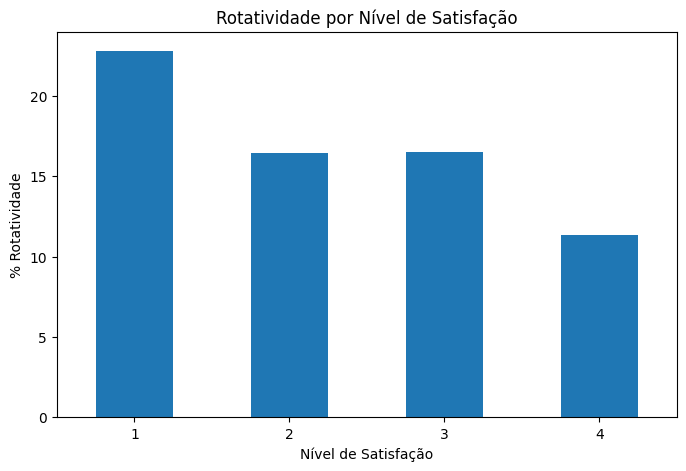

In [233]:
# Iremos analisar agora a influência que o nivel de satisfação possui com a rotatividade.
plt.figure(figsize=(8,5))
satisfacao = df.groupby('JobSatisfaction')['Attrition'].apply(lambda x: (x=='Sim').mean()*100)
satisfacao.plot(kind='bar')
plt.title('Rotatividade por Nível de Satisfação')
plt.xlabel('Nível de Satisfação')
plt.ylabel('% Rotatividade')
plt.xticks(rotation=0)
plt.show()

Com o gráfico gerado podemos perceber que quanto menor o nível de satisfação, maior a probabilidade de saída, o que pode influenciar a decisão de saída dos colaboradores da companhia.

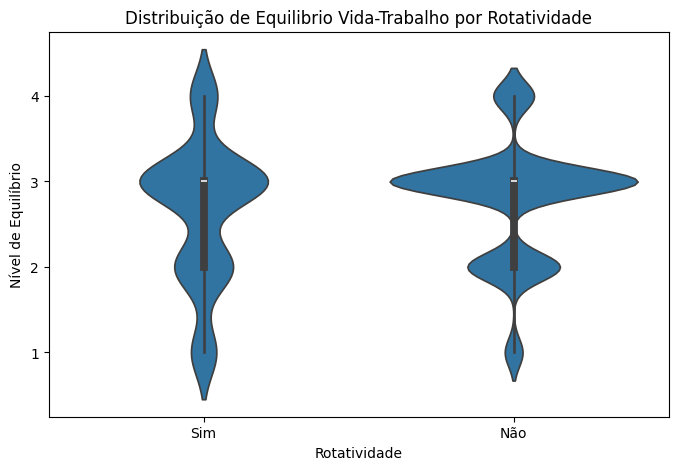

In [234]:
# Vamos analisar agora relação de rotatividade com o equilíbrio entre vida e trabalho, utilizando o gráfico de violino.
plt.figure(figsize=(8,5))
sns.violinplot(x='Attrition', y='WorkLifeBalance', data=df)
plt.ylabel('Nível de Equilíbrio')
plt.xlabel('Rotatividade')
plt.title('Distribuição de Equilibrio Vida-Trabalho por Rotatividade')
plt.show()

Observa-se concentração predominante no nível 3 para ambos os grupos, indicando que a maior parte dos colaboradores percebe equilíbrio satisfatório entre vida e trabalho.

Entretanto, o grupo de colaboradores que saiu apresenta distribuição mais dispersa entre os níveis 1, 2 e 4, enquanto os que permaneceram demonstram maior concentração em níveis intermediários.

## Boxplot

Para melhor entender a rotatividade da área de vendas, utilizaremos o gráfico de boxplot para entender o comportamento dos colaboradores que possuem rotatividade comparando com o atributo de salário.

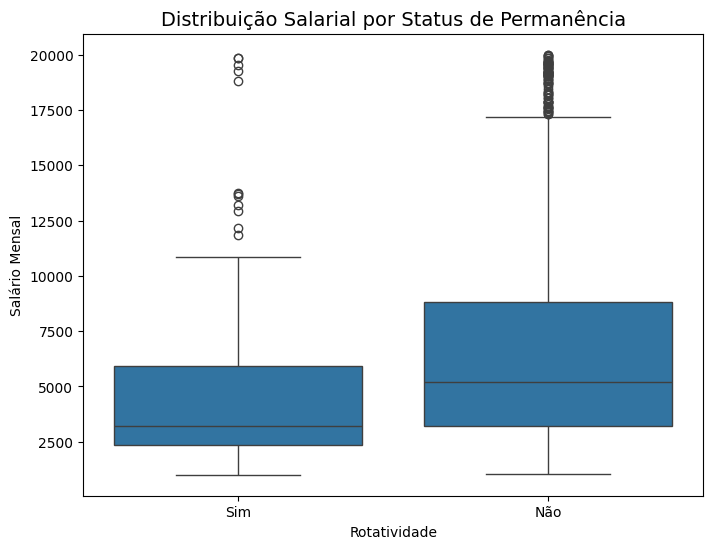

In [235]:
# O boxplot a seguir tem o objetivo de demonstrar a distribuição salarial por rotatividade
plt.figure(figsize=(8,6))
sns.boxplot(data=df,x='Attrition',y='MonthlyIncome')
plt.title('Distribuição Salarial por Status de Permanência', fontsize=14)
plt.xlabel('Rotatividade')
plt.ylabel('Salário Mensal')
plt.show()

Podemos notar nesse gráfico que quem optou pela rotatividade possui uma média salarial inferior aos que não optaram, reforçando que a média salarial dos colaboradores que sairam era menor. Notamos também a presença de muitos outliers em comparação de quem não optou pela rotatividade.

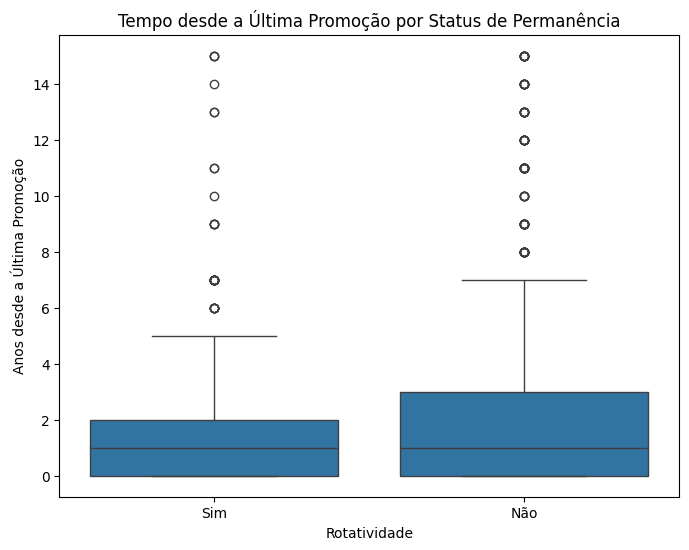

In [236]:
# Vamos analisar também o agrupamento do tempo desde a ultima promoção para verificar variações
plt.figure(figsize=(8,6))
sns.boxplot(data=df,x='Attrition',y='YearsSinceLastPromotion')
plt.title('Tempo desde a Última Promoção por Status de Permanência')
plt.xlabel('Rotatividade')
plt.ylabel('Anos desde a Última Promoção')
plt.show()

Podemos analisar que a linha mediana de ambas as box estão iguais, o que pode direcionar a pensarmos que esse não é um motivo central para esclarecer a rotatividade da área de vendas.

## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

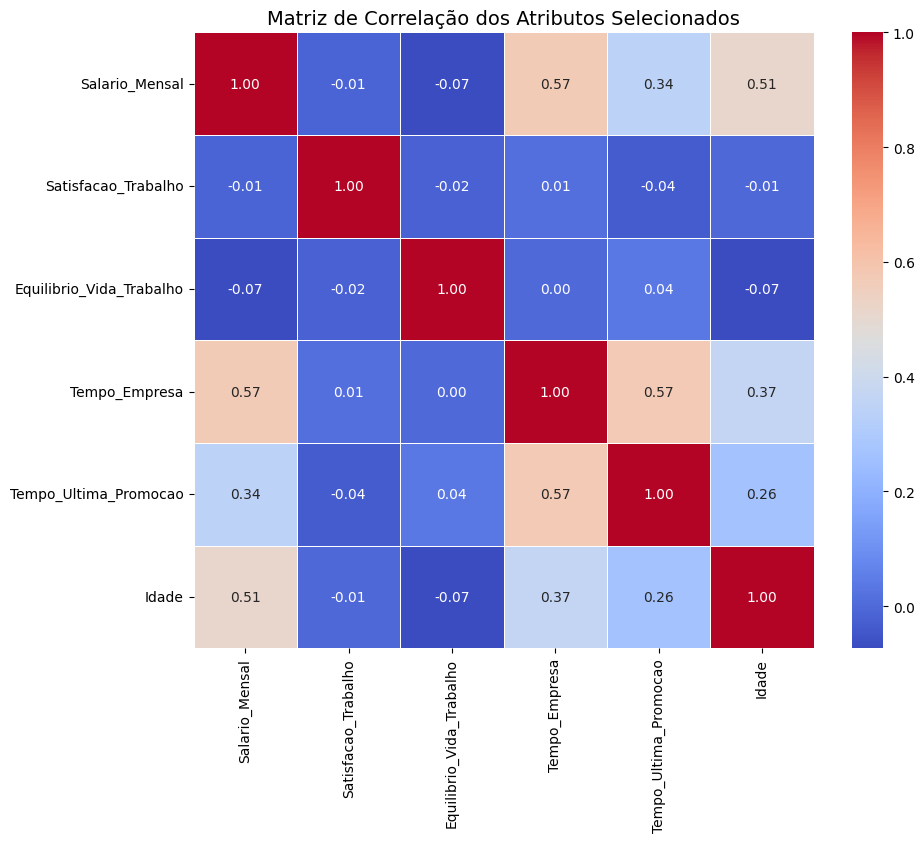

In [237]:
# Vamos analisar todos os atributos numéricos e suas relações entre si.
plt.figure(figsize=(10,8))
sns.heatmap(df_analise.corr(),annot=True,cmap='coolwarm',fmt='.2f',
            linewidths=0.5)
plt.title('Matriz de Correlação dos Atributos Selecionados', fontsize=14)
plt.show()

Ao analisar a matriz de correlação temos correlações mais positivas que estão associadas a idade, tempo de empresa e tempo da ultima promoção o que nos induz a entender que há uma certa lógica, quanto maior a idade, maior o tempo de empresa e consequentemente maior salário. Observamos também que os atributos de satisfação e equilibrio de vida não variam linearmente com os demais atributos.

# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.


A análise exploratória indicou maior índice de rotatividade no departamento de Vendas. Por isso, na etapa de análise de dados foi criada uma visão específica do dataset contendo apenas colaboradores dessa área, denominada df_vendas, com objetivo de aprofundar as análises e preparar uma base mais aderente ao problema identificado e esta que será utilizada para tratativas de pré-processamento.

## Valores Nulos e Duplicados

A verificação de valores ausentes e registros duplicados foi realizada inicialmente no dataset original, antes da criação de subconjuntos analíticos, garantindo que as análises posteriores fossem conduzidas sobre dados íntegros. Porém, vamos aplicar novamente no dataset atual.

In [238]:
# Verificação dos valores duplicados
df_vendas.duplicated().sum()

np.int64(0)

In [239]:
# Verificação se há dados nulos no dataset
df_vendas.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


## *Feature selection*

Observando o dataset atual, notamos que existem várias colunas atualmente relevantes para as análises propostas, então iremos remove-las a fim de limpar o dataset atual.

In [240]:
# O dataset atual contam com 35 colunas
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 446 entries, 0 to 1468
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       446 non-null    int64 
 1   Attrition                 446 non-null    object
 2   BusinessTravel            446 non-null    object
 3   DailyRate                 446 non-null    int64 
 4   Department                446 non-null    object
 5   DistanceFromHome          446 non-null    int64 
 6   Education                 446 non-null    int64 
 7   EducationField            446 non-null    object
 8   EmployeeCount             446 non-null    int64 
 9   EmployeeNumber            446 non-null    int64 
 10  EnvironmentSatisfaction   446 non-null    int64 
 11  Gender                    446 non-null    object
 12  HourlyRate                446 non-null    int64 
 13  JobInvolvement            446 non-null    int64 
 14  JobLevel                  446 

In [241]:
# Definir a lista de colunas a serem mantidas
colunas_para_manter = ['Age', 'Attrition', 'Department', 'Gender',
                       'JobSatisfaction', 'MonthlyIncome', 'TotalWorkingYears',
                       'WorkLifeBalance', 'YearsAtCompany',
                       'YearsSinceLastPromotion']

# Identificar as colunas a serem removidas (todas as que não estão na lista de manter)
colunas_para_remover = [col for col in df_vendas.columns if col not in colunas_para_manter]

# Remover as colunas irrelevantes
df_vendas.drop(columns=colunas_para_remover, inplace=True, errors='ignore')
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 446 entries, 0 to 1468
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      446 non-null    int64 
 1   Attrition                446 non-null    object
 2   Department               446 non-null    object
 3   Gender                   446 non-null    object
 4   JobSatisfaction          446 non-null    int64 
 5   MonthlyIncome            446 non-null    int64 
 6   TotalWorkingYears        446 non-null    int64 
 7   WorkLifeBalance          446 non-null    int64 
 8   YearsAtCompany           446 non-null    int64 
 9   YearsSinceLastPromotion  446 non-null    int64 
dtypes: int64(7), object(3)
memory usage: 38.3+ KB


In [242]:
# Para melhor análise vamos traduzir os atributos
df_vendas.rename(columns={'Age': 'Idade','Attrition': 'Rotatividade',
                          'Department': 'Departamento','Gender': 'gênero',
                          'JobSatisfaction': 'Satisfacao_Trabalho',
                          'MonthlyIncome': 'Salario_Mensal',
                          'TotalWorkingYears': 'Tempo_Total_Carreira',
                          'WorkLifeBalance': 'Equilibrio_Vida_Trabalho',
                          'YearsAtCompany': 'Tempo_Empresa',
                          'YearsSinceLastPromotion': 'Tempo_Ultima_Promocao'},
                 inplace=True)
df_vendas.head()

,Idade,Rotatividade,Departamento,gênero,Satisfacao_Trabalho,Salario_Mensal,Tempo_Total_Carreira,Equilibrio_Vida_Trabalho,Tempo_Empresa,Tempo_Ultima_Promocao
0,41,Sim,Vendas,Female,4,5993,8,1,6,0
18,53,Não,Vendas,Female,4,15427,31,3,25,3
21,36,Sim,Vendas,Male,1,3407,10,3,5,0
27,42,Não,Vendas,Male,2,6825,10,3,9,4
29,46,Não,Vendas,Female,1,18947,22,2,2,2


Agora o dataset encontra-se com menos colunas o que torna mais limpo e com os dados objetivados a análise.

## One-hot encoding/dummy encoding

possuímos dados que estão categorizados como não-numéricos são eles gênero e Rotatitividade, utilizaremos a técnica de Dummy Enconding para converter esses dados para váriaveis binárias.

In [243]:
# Aplicando One-Hot Encoding para os atribudos de gênero e Rotatividade convertendo para variáveis binárias (0 e 1)

# Criamos uma nova cópia do dataset, para que não altere o dataset em análise
df_ohe = df_vendas.copy()

# Traduzindo os valores da coluna 'gênero' antes do One-Hot Encoding
df_ohe['gênero'] = df_ohe['gênero'].replace({'Female': 'Feminino', 'Male': 'Masculino'})

# One-Hot Encoding nas colunas gênero e Rotatividade
df_ohe = pd.get_dummies(df_ohe,columns=['gênero', 'Rotatividade'],drop_first=True,
                        dtype=int)

# Visualizando resultado
df_ohe[['gênero_Masculino','Rotatividade_Sim']].head()

,gênero_Masculino,Rotatividade_Sim
0,0,1
18,0,0
21,1,1
27,1,0
29,0,0


## Padronização

Alguns dos nossos dados possuem escalas diferentes como Salário, Idade, Anos na companhia e Anos Desde a Ultima Promoção, diante disso vamos aplicar a padronização nesse dados.

In [244]:
# Vamos padronizar as colunas descritas
colunas_padronizar = ['Salario_Mensal','Idade','Tempo_Empresa',
                      'Tempo_Ultima_Promocao']
scaler = StandardScaler()
df_ohe[colunas_padronizar] = scaler.fit_transform(df_ohe[colunas_padronizar])
df_ohe.head()

,Idade,Departamento,Satisfacao_Trabalho,Salario_Mensal,Tempo_Total_Carreira,Equilibrio_Vida_Trabalho,Tempo_Empresa,Tempo_Ultima_Promocao,gênero_Masculino,Rotatividade_Sim
0,0.494033,Vendas,4,-0.238315,8,1,-0.206290,-0.702849,0,1
18,1.824044,Vendas,4,2.088662,31,3,2.844502,0.192781,0,0
21,-0.060139,Vendas,1,-0.876174,10,3,-0.366858,-0.702849,1,1
27,0.604867,Vendas,2,-0.033095,10,3,0.275414,0.491325,1,0
29,1.048204,Vendas,1,2.956901,22,2,-0.848562,-0.105762,0,0


Com os dados atualizados, podemos reavaliar as análises anteriores. Diante disso, iremos gerar uma nova matriz de correlação.

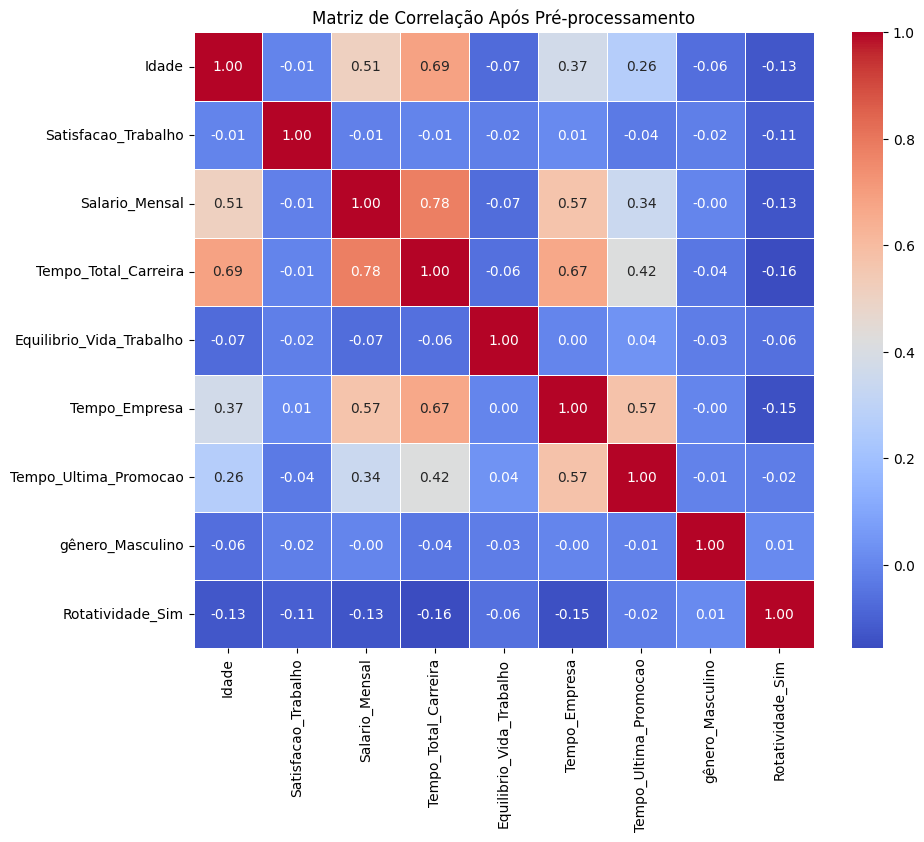

In [245]:
# A partir dos dados padronizados e limpos podemos gerar uma nova matriz de correlação
plt.figure(figsize=(10,8))
sns.heatmap(df_ohe.drop(columns=['Departamento']).corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)
plt.title('Matriz de Correlação Após Pré-processamento')
plt.show()

Com a nova matriz de correlação foi possível observar que a rotatividade não apresenta correlação linear forte com nenhum atributo isolado.

As maiores correlações negativas com a rotatividade foram observadas em Tempo Total de Carreira (-0.16), Tempo de Empresa (-0.15), Idade (-0.13) e Salário Mensal (-0.13), sugerindo que colaboradores mais experientes, antigos e melhor remunerados tendem a permanecer na organização, conforme já havíamos analisado anteriormente.

Por outro lado, o atributo Gênero apresentou correlação praticamente nula (0.01), indicando ausência de influência relevante na saída de colaboradores.

# Resposta às Hipóteses Levantadas

Nesta etapa vamos verificar se as análises serviram para responder as hipóteses levantadas inicialmente.

## Hipótese 1

**Qual departamento apresenta mais rotatividade de colaboradores?**

A hipótese foi confirmada. O departamento de **Vendas** apresentou o maior índice percentual de rotatividade entre os departamentos analisados.

## Hipótese 2

**Colaboradores com menor nível salarial apresentam maior probabilidade de saída?**

A hipótese foi parcialmente confirmada. As análises de média salarial, boxplot e matriz de correlação indicaram que colaboradores que deixaram a empresa possuíam, em média, remuneração inferior aos que permaneceram. Entretanto, a correlação observada foi fraca, sugerindo que o salário, isoladamente, não explica totalmente a rotatividade.

## Hipótese 3

**Baixos níveis de satisfação no trabalho influenciam a decisão de saída?**

A hipótese foi confirmada. O gráfico de rotatividade por nível de satisfação demonstrou tendência clara de redução da saída conforme aumenta o nível de satisfação. Colaboradores com menor satisfação apresentaram maior percentual de rotatividade, indicando que esse fator pode influenciar a permanência na organização.

## Hipótese 4

**O desequilíbrio entre vida pessoal e profissional contribui para a rotatividade?**

A hipótese foi parcialmente confirmada. O gráfico violin plot mostrou que colaboradores que saíram da empresa apresentaram distribuição mais dispersa nos níveis de equilíbrio entre vida pessoal e profissional, especialmente em níveis mais baixos. Apesar disso, a correlação linear observada foi baixa, indicando que o fator pode contribuir, mas não de forma isolada.

## Hipótese 5

**Colaboradores com maior tempo sem promoção tendem a deixar a empresa?**

A hipótese não foi confirmada. Tanto o boxplot quanto a nova matriz de correlação mostraram ausência de relação significativa entre tempo desde a última promoção e rotatividade.

## Hipótese 6

**Há uma correlação entre gênero e a rotatividade?**

A hipótese não foi confirmada. Após a transformação da variável em formato binário, a correlação encontrada entre gênero e rotatividade foi praticamente nula, sugerindo ausência de influência relevante desse atributo sobre a saída de colaboradores.

# Conclusão

Com base nas análises realizadas, foi possível identificar que o departamento de Vendas apresentou o maior índice percentual de rotatividade entre os setores analisados.

Os resultados sugerem que fatores como menor salário mensal, menor tempo de empresa, menor tempo total de carreira e menor idade estão associados à maior propensão à saída de colaboradores.

Também foi observado que baixos níveis de satisfação no trabalho podem contribuir para a rotatividade. Em contrapartida, gênero e tempo desde a última promoção não apresentaram influência relevante quando analisados isoladamente.

A nova matriz de correlação após o pré-processamento reforçou que a rotatividade é um fenômeno multifatorial, não explicado por apenas uma variável.

Como próximos passos, recomenda-se a aplicação de modelos supervisionados de classificação para prever desligamentos futuros e apoiar estratégias preventivas de Recursos Humanos.